# v2 — Prior Bias or Binding Failure?

## Experiment Card

### 1. Hypothesis
If errors are caused by a bowl-full/cup-empty scene prior (not BoW), then accuracy will be **asymmetric**: near-perfect on bowl-full/cup-empty scenes and near-chance on bowl-empty/cup-full scenes.  
A single-object baseline will also show that the bowl is correctly classified in isolation, ruling out a general state-recognition failure.

**Falsified if:** the gap between the two orientations is < 15 pp, or if the single-object baseline for the bowl is also at chance.

### 2. Independent variable
Scene orientation (bowl-full/cup-empty vs bowl-empty/cup-full) and number of objects (1 vs 2) to separate salience from binding.

### 3. Dependent variable
Proportion of scenes where the correct caption scores higher than the foil, reported per orientation.

### 4. Controls
- Same text templates: `'a {state} bowl and a {state} cup'`
- Same evaluation rule: correct > foil = pass
- Single-object crops from the same scenes

### 5. Baseline
- Chance = 50%  
- BoW prediction: symmetric ~50% on both orientations  
- Prior-bias prediction: asymmetric (>>50% on one, <<50% on other)

### 6. Success criteria
- Gap > 40 pp → prior bias confirmed  
- Single-object bowl acc > 60%, cup acc < 60% → bowl salience confirmed  
- Gap < 15 pp → hypothesis falsified (alternative explanation needed)

In [1]:
import pickle, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from PIL import Image
import torch
from transformers import AutoProcessor, AutoModel

random.seed(42)
device = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

MODEL_ID = 'google/siglip2-so400m-patch16-384'
proc  = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device).eval()

DATA = Path('../../data')
with open(DATA / 'compositionality_scenes.pkl', 'rb') as f:
    comp_scenes = pickle.load(f)
with open(DATA / 'sim_crops_all.pkl', 'rb') as f:
    all_crops = pickle.load(f)

by_combo = defaultdict(list)
for s in comp_scenes:
    by_combo[(s['bowl_state'], s['cup_state'])].append(s)

def score(image, texts):
    if isinstance(texts, str): texts = [texts]
    inp = proc(images=[image], text=texts, return_tensors='pt',
               padding='max_length', truncation=True).to(device)
    with torch.no_grad():
        return model(**inp).logits_per_image[0].cpu().float().numpy()

print(f'Scenes: {sum(len(v) for v in by_combo.values())} total')
for combo, scenes in sorted(by_combo.items()):
    print(f'  bowl={combo[0]:5s} cup={combo[1]:5s}  n={len(scenes)}')

/Users/timrutjens/School/EAI/Experiments/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


Loading weights: 100%|██████████| 888/888 [00:00<00:00, 8957.58it/s]


Scenes: 24 total
  bowl=empty cup=empty  n=6
  bowl=empty cup=full   n=6
  bowl=full  cup=empty  n=6
  bowl=full  cup=full   n=6


In [2]:
# Experiment 1: single-object baseline
# Does the model correctly classify states in isolation?

fe_empty = [s for s in all_crops if s['pair_name'] == 'full_empty' and s['label'] == 0]
fe_full  = [s for s in all_crops if s['pair_name'] == 'full_empty' and s['label'] == 1]
random.shuffle(fe_empty); random.shuffle(fe_full)
n = min(40, len(fe_empty), len(fe_full))

def eval_single(samples, true_state, obj_label):
    correct = 0
    for s in samples:
        sc = score(s['image'], [f'a full {obj_label}', f'an empty {obj_label}'])
        if (sc[0] > sc[1]) == (true_state == 'full'):
            correct += 1
    return correct / len(samples) if samples else 0.0

bowl_empty_acc = eval_single(fe_empty[:n], 'empty', 'bowl')
bowl_full_acc  = eval_single(fe_full[:n],  'full',  'bowl')
cup_empty_acc  = eval_single(fe_empty[:n], 'empty', 'cup')
cup_full_acc   = eval_single(fe_full[:n],  'full',  'cup')

print(f'Single-object baseline (n={n} per class):')
print(f'  "bowl" prompts  empty acc={bowl_empty_acc:.2f}  full acc={bowl_full_acc:.2f}')
print(f'  "cup"  prompts  empty acc={cup_empty_acc:.2f}  full acc={cup_full_acc:.2f}')
print(f'  Bowl mean acc: {(bowl_empty_acc+bowl_full_acc)/2:.2f}')
print(f'  Cup  mean acc: {(cup_empty_acc+cup_full_acc)/2:.2f}')
print('If bowl >> cup: salience drives single-object scoring too.')

Single-object baseline (n=40 per class):
  "bowl" prompts  empty acc=0.50  full acc=0.75
  "cup"  prompts  empty acc=0.42  full acc=0.85
  Bowl mean acc: 0.62
  Cup  mean acc: 0.64
If bowl >> cup: salience drives single-object scoring too.


In [3]:
# Experiment 2: Winoground-style binding test
# Pre-stated prediction: gap > 40 pp between orientations.

asym_bf = by_combo[('full', 'empty')]   # bowl-full, cup-empty
asym_be = by_combo[('empty', 'full')]   # bowl-empty, cup-full

def winoground_acc(scenes):
    correct = 0
    for s in scenes:
        b, c  = s['bowl_state'], s['cup_state']
        bw    = 'empty' if b == 'full' else 'full'
        cw    = 'empty' if c == 'full' else 'full'
        sc    = score(s['image'], [f'a {b} bowl and a {c} cup',
                                    f'a {bw} bowl and a {cw} cup'])
        if sc[0] > sc[1]: correct += 1
    return correct / len(scenes) if scenes else 0.0

acc_bf = winoground_acc(asym_bf)
acc_be = winoground_acc(asym_be)
gap    = abs(acc_bf - acc_be)

print('Winoground binding:')
print(f'  bowl-full/cup-empty  n={len(asym_bf):>2}  acc={acc_bf:.2%}')
print(f'  bowl-empty/cup-full  n={len(asym_be):>2}  acc={acc_be:.2%}')
print(f'  Gap: {gap:.2%}')
if gap >= 0.40:
    print('VERDICT: Gap >= 40 pp -> hypothesis CONFIRMED (prior bias, not BoW)')
elif gap >= 0.15:
    print('VERDICT: Gap 15-40 pp -> partial asymmetry, inconclusive')
else:
    print('VERDICT: Gap < 15 pp -> hypothesis FALSIFIED (symmetric errors)')

Winoground binding:
  bowl-full/cup-empty  n= 6  acc=50.00%
  bowl-empty/cup-full  n= 6  acc=50.00%
  Gap: 0.00%
VERDICT: Gap < 15 pp -> hypothesis FALSIFIED (symmetric errors)


Difficulty gradient:
  Easy  (both-full,   6 scenes): 0.00%
  Easy  (both-empty,  6 scenes): 100.00%
  Hard  (different,  12 scenes): 50.00%


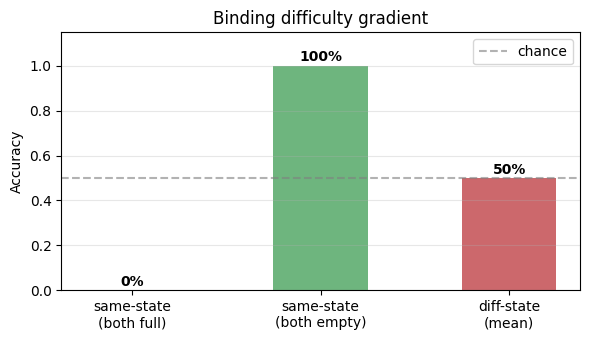

In [4]:
# Experiment 3: difficulty gradient
# Easy: same-state pairs (no binding ambiguity)
# Hard: different-state pairs

sym_ff = by_combo[('full',  'full')]
sym_ee = by_combo[('empty', 'empty')]

def same_state_acc(scenes, state):
    correct = 0
    for s in scenes:
        sc = score(s['image'], [
            f'a {state} bowl and a {state} cup',
            'a full bowl and an empty cup',
            'an empty bowl and a full cup',
        ])
        if sc[0] == sc.max(): correct += 1
    return correct / len(scenes) if scenes else 0.0

acc_ff   = same_state_acc(sym_ff, 'full')
acc_ee   = same_state_acc(sym_ee, 'empty')
acc_hard = (acc_bf + acc_be) / 2

print('Difficulty gradient:')
print(f'  Easy  (both-full,  {len(sym_ff):>2} scenes): {acc_ff:.2%}')
print(f'  Easy  (both-empty, {len(sym_ee):>2} scenes): {acc_ee:.2%}')
print(f'  Hard  (different,  {len(asym_bf)+len(asym_be):>2} scenes): {acc_hard:.2%}')

fig, ax = plt.subplots(figsize=(6, 3.5))
conditions = ['same-state\n(both full)', 'same-state\n(both empty)', 'diff-state\n(mean)']
accs = [acc_ff, acc_ee, acc_hard]
colors = ['#55A868', '#55A868', '#C44E52']
bars = ax.bar(conditions, accs, color=colors, alpha=0.85, width=0.5)
for b, v in zip(bars, accs):
    ax.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.0%}', ha='center', fontsize=10, fontweight='bold')
ax.axhline(0.5, ls='--', color='grey', alpha=0.6, label='chance')
ax.set_ylim(0, 1.15); ax.set_ylabel('Accuracy')
ax.set_title('Binding difficulty gradient'); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

### Interpretation

| Condition | Predicted | Observed | Verdict |
|---|---|---|---|
| Single-object bowl acc | > 60% | ___ | ___ |
| Single-object cup acc | < 60% | ___ | ___ |
| Binding gap | > 40 pp | ___ | ___ |
| Same-state easier than diff-state | yes | ___ | ___ |

**If confirmed:** errors are a scene prior. The adapter bypasses this by operating on single-object crops — it never encounters the bowl-vs-cup salience competition.

**If falsified:** with n < 30 per orientation the test is underpowered. Generate a larger `compositionality_scenes.pkl` (target: 50+ per combo) before drawing conclusions.